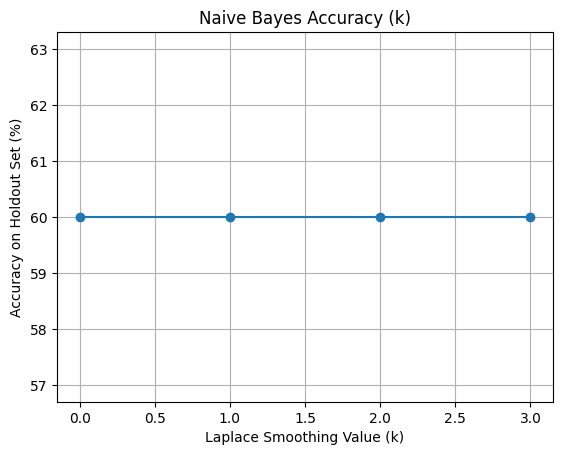


Evaluation_results in held_out data:

{'model_k0': {'correct': 0.6, 'incorrect': 0.4}, 'model_k1': {'correct': 0.6, 'incorrect': 0.4}, 'model_k2': {'correct': 0.6, 'incorrect': 0.4}, 'model_k3': {'correct': 0.6, 'incorrect': 0.4}}


Best model used k = 0, final test accuracy in test_data was: 0.7


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

student_data = pd.read_csv("csv_students_naive_train.csv")

def split_dataset(data):
    total_records = len(data)
    train_limit = int(0.8 * total_records)
    holdout_limit = int(0.9 * total_records)
    
    training_set = data[:train_limit]
    holdout_set = data[train_limit:holdout_limit]
    test_set = data[holdout_limit:]
    
    return training_set, holdout_set, test_set

training_set, holdout_set, test_set = split_dataset(student_data)

def compute_prior_probabilities(data, k=1):
    label_counts = {}
    total = len(data)
    for label in data['GRADE']:
        label_counts[label] = label_counts.get(label, 0) + 1
    all_labels = ['A', 'B', 'C', 'D']
    probabilities = {}
    for label in all_labels:
        probabilities[label] = (label_counts.get(label, 0) + k) / (total + k * len(all_labels))
    return probabilities

def compute_conditional_probabilities(data, features, k=1):
    conditional_probabilities = {}
    grade_labels = ['A', 'B', 'C', 'D']
    for feature in features:
        conditional_probabilities[feature] = {}
        unique_values = data[feature].unique()
        for grade in grade_labels:
            grade_subset = data[data['GRADE'] == grade]
            total_grade_count = len(grade_subset)
            value_counts = grade_subset[feature].value_counts()
            value_probs = {}
            for value in unique_values:
                count = value_counts.get(value, 0)
                value_probs[value] = (count + k) / (total_grade_count + k * len(unique_values))
            conditional_probabilities[feature][grade] = value_probs
    return conditional_probabilities

def predict_grade(instance, prior_probs, cond_probs, features):
    likelihood_scores = {}
    for grade in prior_probs:
        probability = prior_probs[grade]
        for feature in features:
            feature_value = instance[feature]
            probability *= cond_probs[feature][grade].get(feature_value, 0.001)
        likelihood_scores[grade] = probability
    return max(likelihood_scores, key=likelihood_scores.get)

def evaluate_model(data, prior_probs, cond_probs, features):
    correct_predictions = 0
    for i in range(len(data)):
        row = data.iloc[i]
        instance = {feature: row[feature] for feature in features}
        actual_label = row['GRADE']
        predicted_label = predict_grade(instance, prior_probs, cond_probs, features)
        if predicted_label == actual_label:
            correct_predictions += 1
    return correct_predictions / len(data)

selected_features = ['Gender', 'Transportation', 'Accomodation', 'Preparation to midterm', 'Taking notes in classes']
held_out_results = {}

for smoothing_k in [0, 1, 2, 3]:
    prior_probabilities = compute_prior_probabilities(training_set, k=smoothing_k)
    conditional_probabilities = compute_conditional_probabilities(training_set, selected_features, k=smoothing_k)
    accuracy = evaluate_model(holdout_set, prior_probabilities, conditional_probabilities, selected_features)
    held_out_results[f'model_k{smoothing_k}'] = {'correct': accuracy, 'incorrect': 1 - accuracy}

k_values = [0, 1, 2, 3]
accuracies = [held_out_results[f'model_k{k}']['correct'] * 100 for k in k_values]

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Laplace Smoothing Value (k)")
plt.ylabel("Accuracy on Holdout Set (%)")
plt.title("Naive Bayes Accuracy (k)")
plt.grid(True)
plt.show()

best_model_key = max(held_out_results, key=lambda key: held_out_results[key]['correct'])
best_k_value = int(best_model_key[-1])

best_prior_probabilities = compute_prior_probabilities(training_set, k=best_k_value)
best_conditional_probabilities = compute_conditional_probabilities(training_set, selected_features, k=best_k_value)
final_test_accuracy = evaluate_model(test_set, best_prior_probabilities, best_conditional_probabilities, selected_features)

print("\nEvaluation_results in held_out data:\n")

print(held_out_results)

print(f"\n\nBest model used k = {best_k_value}, final test accuracy in test_data was: {final_test_accuracy:}")
